In [29]:

!pip install kneed

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from kneed import KneeLocator



In [6]:
data = pd.read_csv("usuarios_streaming.csv")
data2 = pd.read_csv("perfil_usuarios.csv")
data.head()

,id_cliente,horas_consumo_mensual,gasto_mensual,cantidad_contenidos_vistos,sesiones_semana,porcentaje_finalizacion,tiempo_promedio_sesion_min,cantidad_generos_consumidos,porcentaje_uso_promociones,antiguedad_cliente_meses
0,1001,49,76,3,6,49,56,4,0.785511,28
1,1002,59,396,26,8,88,211,14,0.015691,76
2,1003,43,91,9,3,62,5,2,0.749128,15
3,1004,51,77,8,4,62,5,4,0.510018,5
4,1005,36,212,74,7,51,85,5,0.403138,48


In [7]:
data2.head()

,id_cliente,edad,dispositivos_registrados,porcentaje_uso_app_movil,cantidad_perfiles_creados,interacciones_mensuales_soporte,distancia_promedio_red_km
0,1001,52,2,0.29,5,3,34.1
1,1002,69,3,0.47,5,4,2.4
2,1003,51,1,0.78,1,7,63.6
3,1004,58,2,0.27,3,6,6.5
4,1005,68,5,0.75,4,0,38.5


In [44]:
data_unido = pd.merge(data2, data, on="id_cliente")
data_unido.head()

,id_cliente,edad,dispositivos_registrados,porcentaje_uso_app_movil,cantidad_perfiles_creados,interacciones_mensuales_soporte,distancia_promedio_red_km,horas_consumo_mensual,gasto_mensual,cantidad_contenidos_vistos,sesiones_semana,porcentaje_finalizacion,tiempo_promedio_sesion_min,cantidad_generos_consumidos,porcentaje_uso_promociones,antiguedad_cliente_meses,cluster
0,1001,52,2,0.29,5,3,34.1,49,76,3,6,49,56,4,0.785511,28,1
1,1002,69,3,0.47,5,4,2.4,59,396,26,8,88,211,14,0.015691,76,2
2,1003,51,1,0.78,1,7,63.6,43,91,9,3,62,5,2,0.749128,15,1
3,1004,58,2,0.27,3,6,6.5,51,77,8,4,62,5,4,0.510018,5,1
4,1005,68,5,0.75,4,0,38.5,36,212,74,7,51,85,5,0.403138,48,0


In [11]:
data_unido.shape

(300, 16)

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_unido.drop(columns=["id_cliente"]))

In [15]:
X_scaled

array([[ 0.51595883, -0.77320706, -1.16741631, ..., -0.47637314,
         2.09968611, -0.46574804],
       [ 1.6660419 , -0.05947747, -0.4693709 , ...,  2.5071747 ,
        -1.4473515 ,  1.41132214],
       [ 0.44830689, -1.48693665,  0.73281841, ..., -1.0730827 ,
         1.93204703, -0.97412121],
       ...,
       [ 1.46308606,  1.36798172,  0.96550021, ..., -0.17801835,
         0.34105776, -0.38753678],
       [ 0.38065494,  1.36798172,  1.19818201, ..., -0.47637314,
         0.76815878, -1.44338876],
       [-1.0400359 ,  1.36798172, -0.0040073 , ..., -0.47637314,
        -0.87340928,  0.00351951]])

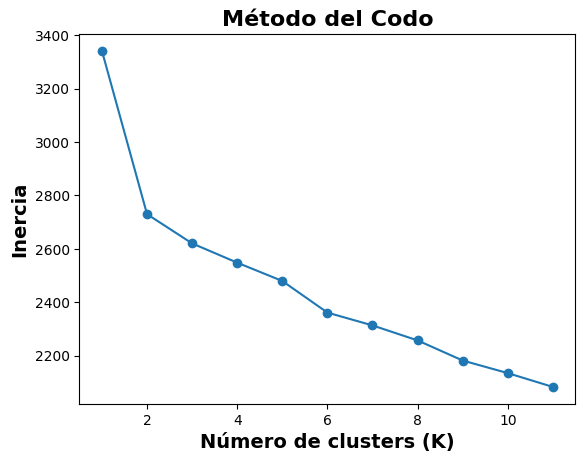

In [45]:
inercia = []
for k in range(2, 13):
    kmeans = KMeans(n_clusters=k, random_state=29)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.plot(range(1, 12), inercia, marker='o')
plt.xlabel("Número de clusters (K)", fontsize=14, fontweight="bold")
plt.ylabel("Inercia", fontsize=14, fontweight="bold")
plt.title("Método del Codo", fontsize=16, fontweight="bold")
plt.show()

In [46]:
kmeans = KMeans(n_clusters=3, random_state=29)
clusters = kmeans.fit_predict(X_scaled)

data_unido["cluster"] = kmeans.labels_

In [47]:
print(f"Silhouette Score: {silhouette_score(X_scaled, data_unido["cluster"]).round(4)}")

Silhouette Score: 0.2311


In [48]:
inertias=[]
silhouettes = []
for k in range(2,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=29,
        n_init=10
    )

    modelo.fit(X_scaled)

    inertias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X_scaled, modelo.labels_))

kl = KneeLocator(
    range(2,11),
    inertias,
    curve='convex',
    direction='decreasing'
)

print("K óptimo:", kl.elbow)

K óptimo: 3


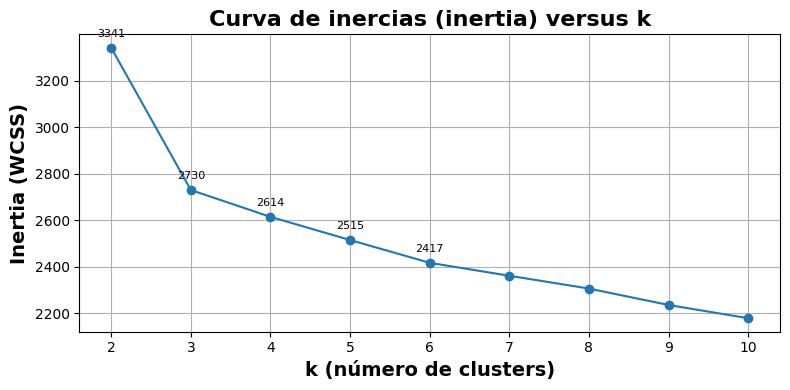

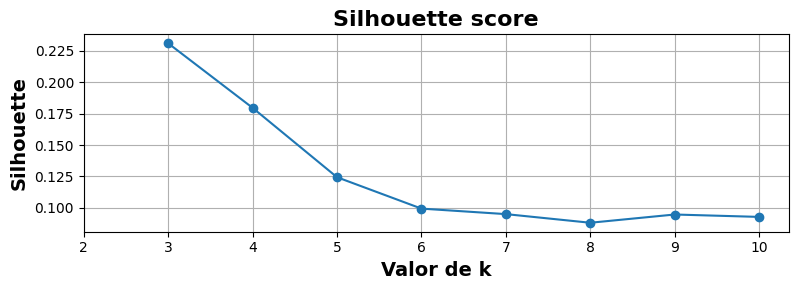

In [32]:

# Graficar inertias (Elbow plot)
range_k = range(2, 11)
plt.figure(figsize=(8,4))
plt.plot(list(range_k), inertias, marker='o')
plt.title("Curva de inercias (inertia) versus k", fontsize=16, fontweight="bold")
plt.xlabel("k (número de clusters)", fontsize=14, fontweight="bold")
plt.ylabel("Inertia (WCSS)", fontsize=14, fontweight="bold")
plt.xticks(list(range_k))

for k_val, val in zip(list(range_k), inertias):
    if k_val <= 6:
        plt.annotate(f"{val:.0f}", (k_val, val), textcoords="offset points", xytext=(0,8), ha='center', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# Grafica el índice de silhoutte
plt.figure(figsize=(8,3))
plt.plot(list(range_k)[1:], silhouettes[1:], marker='o')
plt.title("Silhouette score", fontsize=16, fontweight="bold")
plt.xlabel("Valor de k", fontsize=14, fontweight="bold")
plt.ylabel("Silhouette", fontsize=14, fontweight="bold")
plt.xticks(list(range_k))
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
k_optimo = kl.elbow

kmeans = KMeans(
    n_clusters=k_optimo,
    random_state=29,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

data_unido["cluster"] = clusters

In [50]:
data_unido["cluster"].value_counts()

,count
cluster,
0,112
1,111
2,77


In [51]:
print(f"Silhouette Score: {silhouette_score(X_scaled, data_unido["cluster"]).round(4)}")

Silhouette Score: 0.2311


In [52]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)

Varianza explicada: [0.3192961  0.12949829]


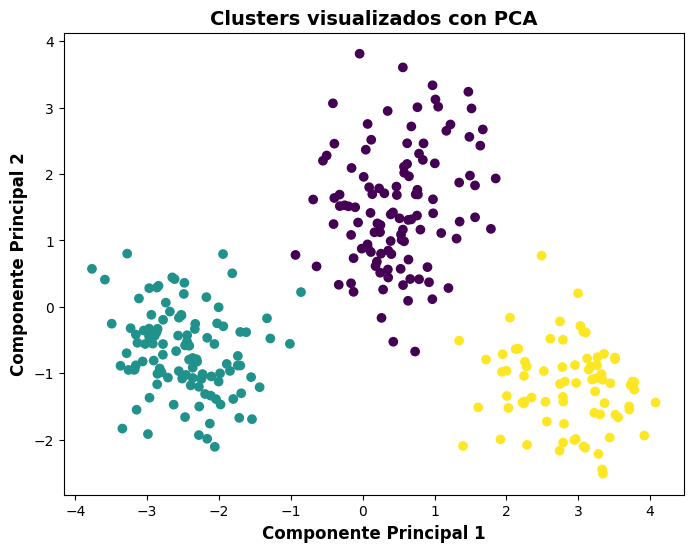

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("Componente Principal 1", fontsize=12, fontweight="bold")
plt.ylabel("Componente Principal 2", fontsize=12, fontweight="bold")
plt.title("Clusters visualizados con PCA", fontsize=14, fontweight="bold")

plt.show()

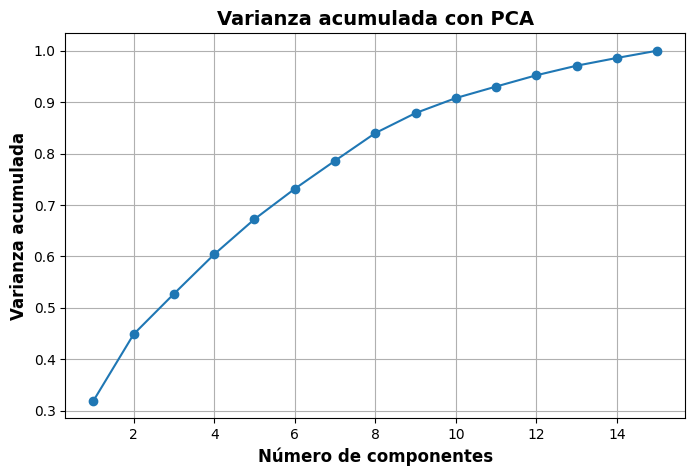

In [54]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

varianza_acumulada = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(varianza_acumulada)+1),
    varianza_acumulada,
    marker='o'
)

plt.xlabel("Número de componentes", fontsize=12, fontweight="bold")
plt.ylabel("Varianza acumulada", fontsize=12, fontweight="bold")
plt.title("Varianza acumulada con PCA", fontsize=14, fontweight="bold")

plt.grid()
plt.show()


In [43]:
componentes = range(1, len(varianza_acumulada)+1)
kl_pca = KneeLocator(
    componentes,
    varianza_acumulada,
    curve="concave",
    direction="increasing"
)

print("Número recomendado de componentes:", kl_pca.knee)

Número recomendado de componentes: 8
